# Analysis Cross-Comparison & Calculated Scores

Cross-compares every source word against every word in the DAT and DIT transcripts using:

- **Levenshtein similarity**
- **Position score** (normalised gap between source and target word index)

Scoring methods:

- **Combined Weighted Score**: $\alpha \cdot \text{lev\_sim} + (1-\alpha) \cdot \text{pos\_sim}$, evaluated for $\alpha \in \{0.25,\ 0.5,\ 0.75\}$
- **Combined Harmonic Score**: $\frac{2 \cdot \text{lev\_sim} \cdot \text{pos\_sim}}{\text{lev\_sim} + \text{pos\_sim}}$


## Imports


In [ ]:
import sys
import pandas as pd
from pathlib import Path
sys.path.insert(0, "scripts")

from domain.calculations import clean
from domain.cross_comparison import generate_cross_comparison_df
from util.plot_helpers import plot_score_distribution


In [ ]:
PROJECT_ROOT = Path.cwd()
ANALYSIS_DIR = PROJECT_ROOT / "samples" / "zurich_subset" / "transcripts"

DIALECT_AWARE_TRANSCRIPT = ANALYSIS_DIR / "dialect-aware-transcript.tsv"
DIALECT_IGNORANT_TRANSCRIPT = ANALYSIS_DIR / "dialect-ignorant-transcript.tsv"


## Select DIT & DAT and load data in df


In [10]:
df_dat = pd.read_csv(DIALECT_AWARE_TRANSCRIPT, sep="\t", encoding="utf-8-sig")
df_dit = pd.read_csv(DIALECT_IGNORANT_TRANSCRIPT, sep="\t", encoding="utf-8-sig")

df = pd.merge(
    df_dat,
    df_dit[["path", "transcript"]],
    on="path",
    how="inner",
    suffixes=("_dit", "_dat"),
)
df = df.rename(columns={"transcript_dit": "DIT", "transcript_dat": "DAT"})
df.head()

,path,duration,sentence,sentence_source,client_id,dialect_region,canton,zipcode,age,gender,DIT,DAT
0,clips/300bb931-79ae-40ec-b989-3efd5e83f4c2/83c...,4.778662,Insgesamt habe ich einige Hunderttausend Frank...,news,300bb931-79ae-40ec-b989-3efd5e83f4c2,Zürich,ZH,8408.0,fourties,male,Insgesamt habe ich einige Hunderttausend Frank...,Insgesamt habe ich einige hunderttausend Frank...
1,clips/6e084270-8d26-43d9-ba69-5e8ee793ab8c/dca...,5.294150,Welche Rolle hatte Rosenberg während des Holoc...,news,6e084270-8d26-43d9-ba69-5e8ee793ab8c,Zürich,ZG,6340.0,twenties,female,Welche Rolle hatte Rosenberg während des Holoc...,Welche Rolle hatte Rausenberg während des Holo...
2,clips/6858a37b-edd0-4fdf-871c-96d3b1bd3e21/82f...,5.802676,Das ist angesichts aller schlechten Optionen d...,news,6858a37b-edd0-4fdf-871c-96d3b1bd3e21,Zürich,ZH,8704.0,fourties,male,Das ist angesichts aller schlechten Optionen d...,Das ist angesichts aller schlechten Optionen d...
3,clips/c4c03e6f-50a2-4d24-ae88-caf3032798fa/a21...,5.973333,Ebenfalls keinen Sieg durfte die AC Milan feiern.,news,c4c03e6f-50a2-4d24-ae88-caf3032798fa,Zürich,AG,4663.0,fourties,male,Ebenfalls keinen Sieg durfte AC Milan feiern.,Ebenfalls kein Sieg durfte AC Milan feiern.
4,clips/f877ee50-af2b-423b-bdda-0cc406032c45/4e5...,4.778662,Viele Fussballfans haben die Alte Reithalle un...,parliament,f877ee50-af2b-423b-bdda-0cc406032c45,Zürich,ZH,8405.0,fourties,female,Viele Fussballfans haben die alte Reithalle un...,Viele Fussballfans haben die Alt-Rheintaler un...


## Max Word & Sentence Length


In [5]:
all_words = (
    df["sentence"].dropna().str.split().explode().tolist()
    + df["DIT"].dropna().str.split().explode().tolist()
    + df["DAT"].dropna().str.split().explode().tolist()
)
all_sentences = pd.concat(
    [df["sentence"].dropna(), df["DIT"].dropna(), df["DAT"].dropna()]
)

global_max_word_length = max(len(clean(w)) for w in all_words)
global_max_sentence_length = max(len(str(s).split()) for s in all_sentences)

print(f"Global max word length: {global_max_word_length}")
print(f"Global max sentence length: {global_max_sentence_length}")

Global max word length: 22
Global max sentence length: 20


## Analysis


### Build word-level DataFrames


In [ ]:
word_comparison_results = generate_cross_comparison_df(
    df, global_max_word_length, global_max_sentence_length, alpha=0.4
)
word_comparison_results.head()

### Comparative summary statistics

In [245]:
# Alpha-independent scores
word_comparison_results[
    [
        "dit_word_score",
        "dat_word_score",
        "position_score",
        "dit_score_harmonic",
        "dat_score_harmonic",
        "dit_score_weighted",
        "dat_score_weighted"
    ]
].describe().round(3)

,dit_word_score,dat_word_score,position_score,dit_score_harmonic,dat_score_harmonic,dit_score_weighted,dat_score_weighted
count,7347.000,7347.000,7347.000,7347.000,7347.000,7347.000,7347.000
mean,0.784,0.780,0.829,0.795,0.793,0.811,0.810
std,0.133,0.129,0.142,0.122,0.119,0.111,0.108
min,0.192,0.038,0.000,0.000,0.000,0.246,0.246
25%,0.692,0.692,0.737,0.729,0.734,0.750,0.750
50%,0.808,0.808,0.842,0.804,0.804,0.827,0.827
75%,0.885,0.846,0.947,0.870,0.870,0.876,0.876
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### Full Word-to-Word Cross-Comparison: Single Clip (index 2)

Exhaustive mapping of every source word against every word in the DIT and DAT transcripts for a single example clip.


In [246]:
clip_index = 2
example_clip_id = df.iloc[clip_index]["path"]

print(f"Clip ID: {example_clip_id}")
print(f"Source: {df.iloc[clip_index]['sentence']}")
print(f"DIT: {df.iloc[clip_index]['DIT']}")
print(f"DAT: {df.iloc[clip_index]['DAT']}")

base_cols = [
    "src_word_index",
    "dit_word_index",
    "dat_word_index",
    "src_word",
    "dit_word",
    "dat_word",
    "dit_word_score",
    "dat_word_score",
    "position_score",
    "dit_score_harmonic",
    "dat_score_harmonic",
    "dit_score_weighted",
    "dat_score_weighted",
]
example_clip_cross_comparison_df = word_comparison_results.loc[
    word_comparison_results["clip_id"] == example_clip_id, base_cols
].reset_index(drop=True)

Clip ID: clips/6858a37b-edd0-4fdf-871c-96d3b1bd3e21/82f96cf51a7b4d1239325b81c305870fd7e997b57e21c307560debad119e0417.flac
Source: Das ist angesichts aller schlechten Optionen die beste.
DIT: Das ist angesichts aller schlechten Optionen die beste.
DAT: Das isch angesichts vo allne schlechte Optione die Best.


In [247]:
dit_all_pairs_cols = [
    "src_word_index",
    "dit_word_index",
    "src_word",
    "dit_word",
    "dit_word_score",
    "position_score",
    "dit_score_harmonic",
    "dit_score_weighted",
]
df_cross_compare_dit = (
    example_clip_cross_comparison_df[dit_all_pairs_cols]
    .sort_values(["src_word_index", "dit_word_index"])
    .reset_index(drop=True)
)
df_cross_compare_dit

,src_word_index,dit_word_index,src_word,dit_word,dit_word_score,position_score,dit_score_harmonic,dit_score_weighted
0,0,0,das,das,1.000,1.000,1.000,1.000
1,0,1,das,ist,0.885,0.947,0.915,0.922
2,0,2,das,angesichts,0.654,0.895,0.756,0.799
3,0,3,das,aller,0.808,0.842,0.825,0.828
4,0,4,das,schlechten,0.615,0.789,0.691,0.719
...,...,...,...,...,...,...,...,...
59,7,3,beste,aller,0.808,0.789,0.798,0.797
60,7,4,beste,schlechten,0.731,0.842,0.783,0.798
61,7,5,beste,optionen,0.731,0.895,0.805,0.829
62,7,6,beste,die,0.846,0.947,0.894,0.907


In [248]:
dat_all_pairs_cols = [
    "src_word_index",
    "dat_word_index",
    "src_word",
    "dat_word",
    "dat_word_score",
    "position_score",
    "dat_score_harmonic",
    "dat_score_weighted",
]
df_cross_compare_dat = (
    example_clip_cross_comparison_df[dat_all_pairs_cols]
    .sort_values(["src_word_index", "dat_word_index"])
    .reset_index(drop=True)
)
df_cross_compare_dat

,src_word_index,dat_word_index,src_word,dat_word,dat_word_score,position_score,dat_score_harmonic,dat_score_weighted
0,0,0,das,das,1.000,1.000,1.000,1.000
1,0,1,das,isch,0.846,0.947,0.894,0.907
2,0,2,das,angesichts,0.654,0.895,0.756,0.799
3,0,3,das,vo,0.885,0.842,0.863,0.859
4,0,4,das,allne,0.808,0.789,0.798,0.797
...,...,...,...,...,...,...,...,...
59,7,3,beste,vo,0.808,0.789,0.798,0.797
60,7,4,beste,allne,0.846,0.842,0.844,0.844
61,7,5,beste,schlechte,0.769,0.895,0.827,0.845
62,7,6,beste,optione,0.769,0.947,0.849,0.876


### Score distributions


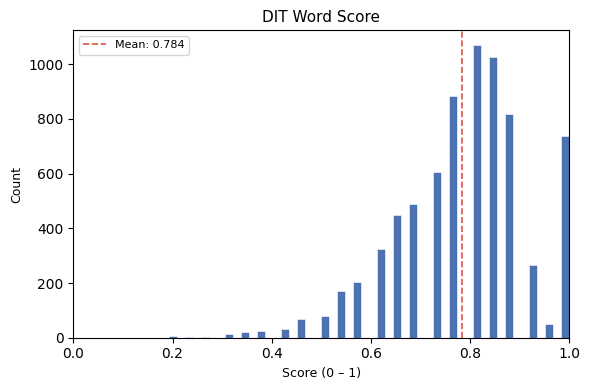

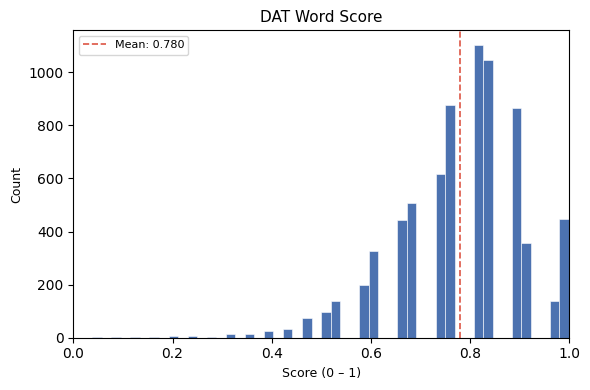

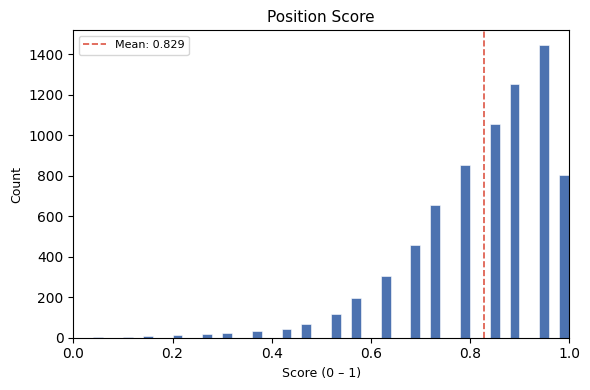

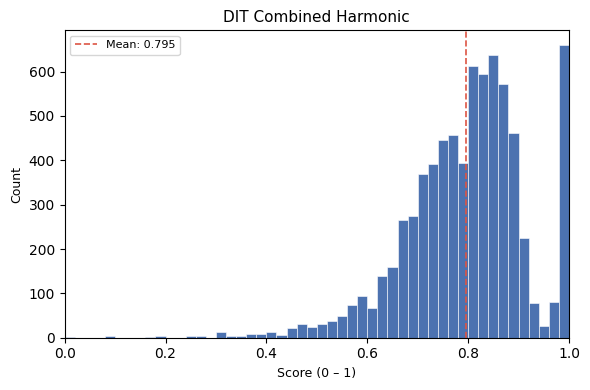

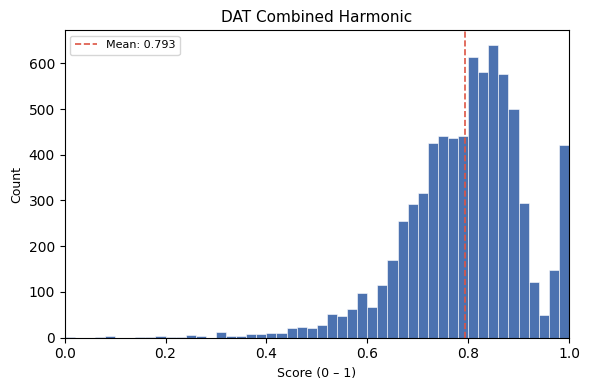

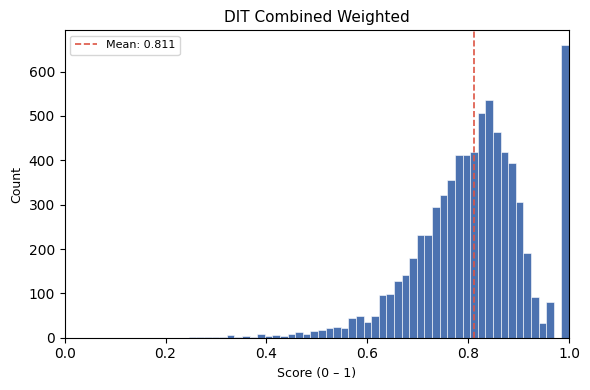

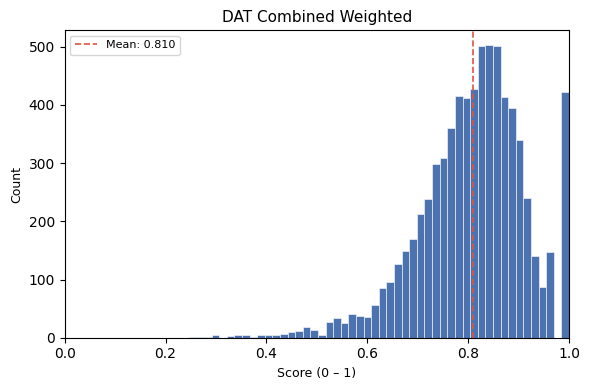

In [249]:
plot_score_distribution(word_comparison_results["dit_word_score"], "DIT Word Score")
plot_score_distribution(word_comparison_results["dat_word_score"], "DAT Word Score")
plot_score_distribution(word_comparison_results["position_score"], "Position Score")
plot_score_distribution(
    word_comparison_results["dit_score_harmonic"], "DIT Combined Harmonic"
)
plot_score_distribution(
    word_comparison_results["dat_score_harmonic"], "DAT Combined Harmonic"
)
plot_score_distribution(
    word_comparison_results["dit_score_weighted"], "DIT Combined Weighted"
)
plot_score_distribution(
    word_comparison_results["dat_score_weighted"], "DAT Combined Weighted"
)